In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f
from matplotlib.ticker import AutoMinorLocator

In [3]:
significance_lvl = 0.05
size_1 = 139
size_2 = 1000

df_num = size_1 - 1
df_den = size_2 - 1

In [4]:
lower_crit_val = f.ppf(significance_lvl / 2, df_num, df_den)
print("Нижняя граница (квантиль {0}): {1:.6f}".format(significance_lvl/2, lower_crit_val))

Нижняя граница (квантиль 0.025): 0.767382


In [5]:
upper_crit_val = f.ppf(1 - significance_lvl / 2, df_num, df_den)
print("Верхняя граница (квантиль {0}): {1:.6f}".format(1 - significance_lvl/2, upper_crit_val))

Верхняя граница (квантиль 0.975): 1.271697


In [6]:
std_x_len, std_y_len = 5.722, 6.161
std_x_wid, std_y_wid = 4.612, 5.055

In [7]:
f_stat_length = (std_x_len ** 2) / (std_y_len ** 2)
print(f"Вычисленная статистика Фишера для признака 'длина': {f_stat_length:.6f}")

Вычисленная статистика Фишера для признака 'длина': 0.862568


In [8]:
f_stat_length = (std_x_len ** 2) / (std_y_len ** 2)
print(f"Вычисленная статистика Фишера для признака 'длина': {f_stat_length:.6f}")

Вычисленная статистика Фишера для признака 'длина': 0.862568


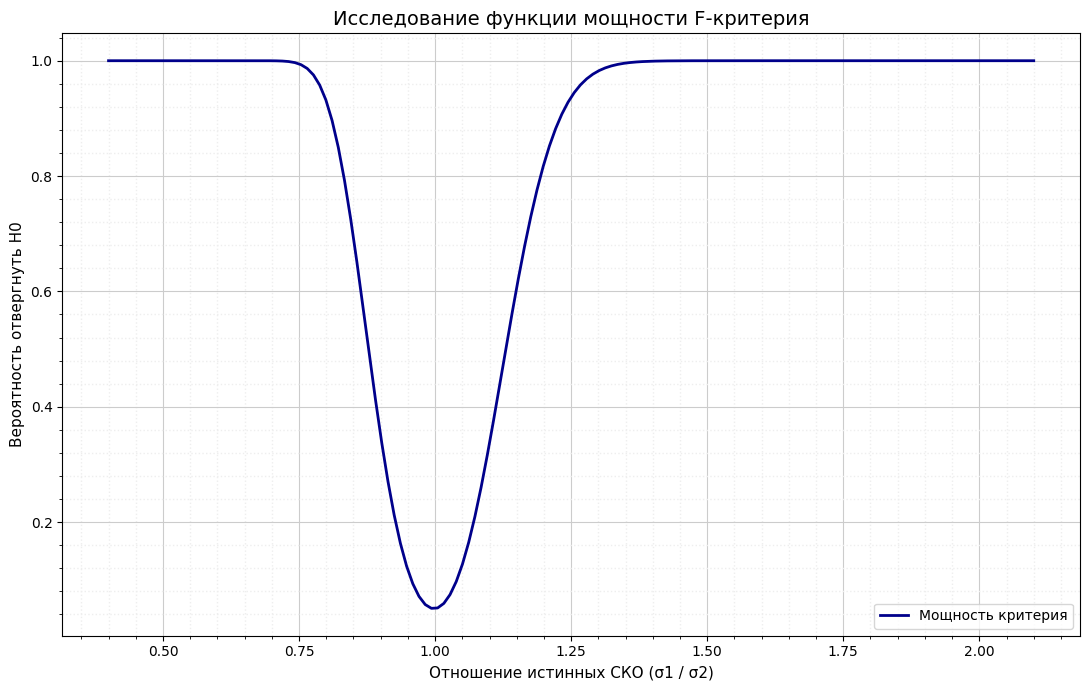

In [10]:
fig, axes = plt.subplots(figsize=(11, 7))

axes.set_title("Исследование функции мощности F-критерия", fontsize=14)
axes.set_xlabel("Отношение истинных СКО (σ1 / σ2)", fontsize=11)
axes.set_ylabel("Вероятность отвергнуть H0", fontsize=11)

ratio_array = np.linspace(0.4, 2.1, 150)
variance_ratio = ratio_array ** 2

power_function = (1 - f.cdf(upper_crit_val, df_num, df_den, scale=variance_ratio) + 
                  f.cdf(lower_crit_val, df_num, df_den, scale=variance_ratio))

axes.plot(ratio_array, power_function, color="darkblue", linewidth=2, label="Мощность критерия")

axes.xaxis.set_minor_locator(AutoMinorLocator(5))
axes.yaxis.set_minor_locator(AutoMinorLocator(5))

plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8)
plt.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)

plt.legend(loc="lower right") 
plt.tight_layout()
plt.show()